# 三个模型 Main Table 对比

本 notebook 读取以下三个实验目录的评估结果，并复用 `encode_anlysis.ipynb` 的主表口径计算 `Main table (paper)`：

- `decode_eval_cc_add_v2_best`
- `decode_eval_cc_concat_v7_best`
- `decode_eval_cc_only_v1_best`

仅包含：读取数据 + 计算主表。

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

WORK_DIRS = {
    "add_v2": Path("/home/xucong24/Compiler/work_dirs/decode_eval_cc_add_v2_best"),
    "concat_v7": Path("/home/xucong24/Compiler/work_dirs/decode_eval_cc_concat_v7_best"),
    "only_v1": Path("/home/xucong24/Compiler/work_dirs/decode_eval_cc_only_v1_best"),
}

REWARD_THRESHOLD = 0.5


In [2]:
def geomean_positive(x):
    x = pd.Series(x).dropna()
    x = x[x > 0]
    if len(x) == 0:
        return np.nan
    return float(np.exp(np.log(x).mean()))


def bootstrap_mean_ci(x, n_boot=3000, alpha=0.05, rng=None):
    if rng is None:
        rng = np.random.default_rng(42)
    x = pd.Series(x).dropna().to_numpy(dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    means = []
    for _ in range(n_boot):
        means.append(rng.choice(x, size=len(x), replace=True).mean())
    lower = float(np.quantile(means, alpha / 2))
    upper = float(np.quantile(means, 1 - alpha / 2))
    return float(x.mean()), lower, upper


def build_main_table(df, model_name):
    # 与 encode_anlysis.ipynb 保持一致：先做 reward 过滤
    if "reward_max" in df.columns:
        df = df[df["reward_max"] >= REWARD_THRESHOLD].copy()
    elif "reward" in df.columns:
        df = df[df["reward"] >= REWARD_THRESHOLD].copy()

    # 缺省值处理
    for col in ["sampling_key", "error_message"]:
        if col in df.columns:
            df[col] = df[col].fillna("")
    if "temperature" in df.columns:
        df["temperature"] = pd.to_numeric(df["temperature"], errors="coerce")

    # 基线 greedy（按 benchmark 配对）
    greedy_base = (
        df[df["strategy"] == "greedy"][["benchmark", "reward_max", "ic_reduction"]]
        .drop_duplicates(subset=["benchmark"])
        .rename(columns={"reward_max": "greedy_reward", "ic_reduction": "greedy_ic"})
    )

    groups = []
    for mode in ["greedy", "beam", "sampling_topp"]:
        sub = df[df["strategy"] == mode].copy()
        if len(sub) > 0:
            groups.append((mode, np.nan, "", sub))

    samp = df[df["strategy"] == "sampling"].copy()
    if len(samp) > 0:
        for temp, sub in samp.groupby("temperature", dropna=False):
            key = ""
            if "sampling_key" in sub.columns and sub["sampling_key"].notna().any():
                key = str(sub["sampling_key"].iloc[0])
            groups.append(("sampling", float(temp) if pd.notna(temp) else np.nan, key, sub.copy()))

        # sampling_best_temp（每个 benchmark 取最优温度）
        samp_best = (
            samp.sort_values(["benchmark", "reward_max"], ascending=[True, False])
            .groupby("benchmark", as_index=False)
            .head(1)
            .copy()
        )
        groups.append(("sampling_best_temp", np.nan, "best_of_temps", samp_best))

    rng = np.random.default_rng(42)
    rows = []
    for mode, temp, key, sub in groups:
        paired = sub[["benchmark", "reward_max", "ic_reduction"]].merge(greedy_base, on="benchmark", how="inner")
        delta_reward = paired["reward_max"] - paired["greedy_reward"]
        delta_ic = paired["ic_reduction"] - paired["greedy_ic"]

        _, dr_l, dr_u = bootstrap_mean_ci(delta_reward, rng=rng)
        _, di_l, di_u = bootstrap_mean_ci(delta_ic, rng=rng)

        rows.append({
            "model": model_name,
            "mode": mode,
            "temperature": temp,
            "sampling_key": key,
            "total_benchmarks": sub["benchmark"].nunique(),
            "reward_mean": sub["reward_max"].mean(),
            "reward_std": sub["reward_max"].std(),
            "ic_reduction_mean": sub["ic_reduction"].mean(),
            "ic_reduction_std": sub["ic_reduction"].std(),
            "delta_ic_vs_greedy": delta_ic.mean() if len(delta_ic) else np.nan,
            "delta_ic_ci_low": di_l,
            "delta_ic_ci_high": di_u,
            "win_rate_vs_greedy": (delta_ic > 0).mean() if len(delta_ic) else np.nan,
            "wall_time_mean": sub["wall_time_total"].mean() if "wall_time_total" in sub.columns else np.nan,
            "inference_time_mean": sub["inference_time"].mean() if "inference_time" in sub.columns else np.nan,
            "eval_time_mean": sub["eval_time"].mean() if "eval_time" in sub.columns else np.nan,
        })

    out = pd.DataFrame(rows)
    return out.sort_values(["model", "mode", "temperature"], na_position="first").reset_index(drop=True)


In [3]:
all_tables = []
for model_name, wd in WORK_DIRS.items():
    csv_path = wd / "decode_all_results.csv"
    df_model = pd.read_csv(csv_path)
    mt = build_main_table(df_model, model_name)
    all_tables.append(mt)

main_table_all = pd.concat(all_tables, ignore_index=True)

print("=== Main table (paper) for all three models ===")
display(main_table_all)

for model_name in WORK_DIRS.keys():
    print(f"\n=== Main table (paper): {model_name} ===")
    display(main_table_all[main_table_all["model"] == model_name].reset_index(drop=True))


=== Main table (paper) for all three models ===


,model,mode,temperature,sampling_key,total_benchmarks,reward_mean,reward_std,ic_reduction_mean,ic_reduction_std,delta_ic_vs_greedy,delta_ic_ci_low,delta_ic_ci_high,win_rate_vs_greedy,wall_time_mean,inference_time_mean,eval_time_mean
0,add_v2,beam,NaN,,98,0.981332,0.107205,0.486402,0.098410,-0.000244,-0.000835,0.000458,0.020408,3.239534,0.461653,0.666235
1,add_v2,greedy,NaN,,98,0.981969,0.106698,0.486646,0.098129,0.000000,0.000000,0.000000,0.000000,3.685293,0.819861,0.730189
2,add_v2,sampling,0.2,sample_0.2,98,1.019267,0.102054,0.504613,0.097723,0.017968,0.013932,0.022608,0.857143,142.308142,0.802899,21.584091
3,add_v2,sampling,0.4,sample_0.4,98,1.020480,0.097447,0.505117,0.096611,0.018471,0.014663,0.022288,0.857143,142.308142,0.776092,21.579148
4,add_v2,sampling,0.6,sample_0.6,99,1.022468,0.099775,0.503105,0.096738,0.018825,0.015132,0.022650,0.846939,141.669163,0.772720,21.304790
5,add_v2,sampling,0.8,sample_0.8,99,1.019872,0.104796,0.501648,0.095959,0.017353,0.012838,0.022552,0.816327,141.669163,0.779862,21.595752
6,add_v2,sampling,1.0,sample_1.0,98,1.017879,0.107244,0.503110,0.095496,0.016464,0.012911,0.020426,0.816327,142.308142,0.779994,21.527501
7,add_v2,sampling,1.2,sample_1.2,98,1.022305,0.104864,0.505305,0.094971,0.018659,0.014339,0.023577,0.846939,142.308142,0.770361,21.461977
8,add_v2,sampling_best_temp,NaN,best_of_temps,99,1.042283,0.106022,0.512682,0.097983,0.028500,0.023839,0.034127,0.969388,141.669163,0.775944,21.420606
9,add_v2,sampling_topp,NaN,,98,1.020814,0.102229,0.504770,0.095329,0.018125,0.014460,0.021991,0.867347,23.591874,0.813718,20.744231



=== Main table (paper): add_v2 ===


,model,mode,temperature,sampling_key,total_benchmarks,reward_mean,reward_std,ic_reduction_mean,ic_reduction_std,delta_ic_vs_greedy,delta_ic_ci_low,delta_ic_ci_high,win_rate_vs_greedy,wall_time_mean,inference_time_mean,eval_time_mean
0,add_v2,beam,NaN,,98,0.981332,0.107205,0.486402,0.098410,-0.000244,-0.000835,0.000458,0.020408,3.239534,0.461653,0.666235
1,add_v2,greedy,NaN,,98,0.981969,0.106698,0.486646,0.098129,0.000000,0.000000,0.000000,0.000000,3.685293,0.819861,0.730189
2,add_v2,sampling,0.2,sample_0.2,98,1.019267,0.102054,0.504613,0.097723,0.017968,0.013932,0.022608,0.857143,142.308142,0.802899,21.584091
3,add_v2,sampling,0.4,sample_0.4,98,1.020480,0.097447,0.505117,0.096611,0.018471,0.014663,0.022288,0.857143,142.308142,0.776092,21.579148
4,add_v2,sampling,0.6,sample_0.6,99,1.022468,0.099775,0.503105,0.096738,0.018825,0.015132,0.022650,0.846939,141.669163,0.772720,21.304790
5,add_v2,sampling,0.8,sample_0.8,99,1.019872,0.104796,0.501648,0.095959,0.017353,0.012838,0.022552,0.816327,141.669163,0.779862,21.595752
6,add_v2,sampling,1.0,sample_1.0,98,1.017879,0.107244,0.503110,0.095496,0.016464,0.012911,0.020426,0.816327,142.308142,0.779994,21.527501
7,add_v2,sampling,1.2,sample_1.2,98,1.022305,0.104864,0.505305,0.094971,0.018659,0.014339,0.023577,0.846939,142.308142,0.770361,21.461977
8,add_v2,sampling_best_temp,NaN,best_of_temps,99,1.042283,0.106022,0.512682,0.097983,0.028500,0.023839,0.034127,0.969388,141.669163,0.775944,21.420606
9,add_v2,sampling_topp,NaN,,98,1.020814,0.102229,0.504770,0.095329,0.018125,0.014460,0.021991,0.867347,23.591874,0.813718,20.744231



=== Main table (paper): concat_v7 ===


,model,mode,temperature,sampling_key,total_benchmarks,reward_mean,reward_std,ic_reduction_mean,ic_reduction_std,delta_ic_vs_greedy,delta_ic_ci_low,delta_ic_ci_high,win_rate_vs_greedy,wall_time_mean,inference_time_mean,eval_time_mean
0,concat_v7,beam,NaN,,98,0.990044,0.112108,0.491435,0.100494,-0.003717,-0.008104,-0.000043,0.244898,2.646267,0.410512,0.567358
1,concat_v7,greedy,NaN,,98,0.999452,0.102527,0.495152,0.096416,0.000000,0.000000,0.000000,0.000000,3.089045,0.797455,0.580276
2,concat_v7,sampling,0.2,sample_0.2,99,1.038871,0.105351,0.511051,0.096977,0.018346,0.014377,0.022943,0.948980,125.786569,0.735558,18.926066
3,concat_v7,sampling,0.4,sample_0.4,99,1.034430,0.104288,0.509350,0.098379,0.016628,0.013010,0.020935,0.928571,125.786569,0.724338,19.066020
4,concat_v7,sampling,0.6,sample_0.6,99,1.036700,0.105611,0.509862,0.096617,0.017144,0.013161,0.021749,0.938776,125.786569,0.722175,19.075269
5,concat_v7,sampling,0.8,sample_0.8,99,1.038395,0.102577,0.510834,0.096354,0.018126,0.014174,0.022773,0.948980,125.786569,0.722942,18.954716
6,concat_v7,sampling,1.0,sample_1.0,99,1.034439,0.103437,0.509084,0.097708,0.016359,0.013095,0.020005,0.928571,125.786569,0.719722,19.137635
7,concat_v7,sampling,1.2,sample_1.2,99,1.034123,0.101318,0.509003,0.097632,0.016277,0.013157,0.019629,0.938776,125.786569,0.723661,18.843097
8,concat_v7,sampling_best_temp,NaN,best_of_temps,99,1.048228,0.106401,0.515595,0.097613,0.022936,0.018502,0.028280,0.948980,125.786569,0.717609,18.787003
9,concat_v7,sampling_topp,NaN,,99,1.039723,0.109617,0.511158,0.096902,0.018454,0.014305,0.023810,0.938776,20.350037,0.723625,17.924156



=== Main table (paper): only_v1 ===


,model,mode,temperature,sampling_key,total_benchmarks,reward_mean,reward_std,ic_reduction_mean,ic_reduction_std,delta_ic_vs_greedy,delta_ic_ci_low,delta_ic_ci_high,win_rate_vs_greedy,wall_time_mean,inference_time_mean,eval_time_mean
0,only_v1,beam,NaN,,98,0.984108,0.112795,0.487511,0.098349,-0.001040,-0.005886,0.004717,0.163265,3.316150,0.408170,0.726909
1,only_v1,greedy,NaN,,98,0.985673,0.124359,0.488551,0.101197,0.000000,0.000000,0.000000,0.000000,3.958711,1.019363,0.719182
2,only_v1,sampling,0.2,sample_0.2,99,1.038275,0.122059,0.509721,0.095808,0.023604,0.017124,0.031599,0.938776,143.087380,0.761464,21.602343
3,only_v1,sampling,0.4,sample_0.4,98,1.030172,0.108887,0.508842,0.093917,0.020292,0.015032,0.026821,0.948980,143.735345,0.735610,21.796810
4,only_v1,sampling,0.6,sample_0.6,99,1.029791,0.112530,0.506310,0.097014,0.020158,0.014331,0.027162,0.918367,143.087380,0.738613,21.757019
5,only_v1,sampling,0.8,sample_0.8,98,1.035653,0.119891,0.510752,0.092464,0.022201,0.015476,0.030344,0.857143,143.735345,0.735659,21.781393
6,only_v1,sampling,1.0,sample_1.0,98,1.027316,0.113172,0.507257,0.093682,0.018706,0.013272,0.025495,0.887755,143.735345,0.734710,21.919512
7,only_v1,sampling,1.2,sample_1.2,99,1.028116,0.108063,0.504934,0.093677,0.018768,0.012970,0.025314,0.836735,143.087380,0.733494,21.722259
8,only_v1,sampling_best_temp,NaN,best_of_temps,99,1.051341,0.123728,0.515688,0.094683,0.029631,0.022650,0.038123,0.969388,143.087380,0.735867,21.808901
9,only_v1,sampling_topp,NaN,,99,1.024653,0.108607,0.504136,0.097217,0.017962,0.013367,0.023863,0.908163,23.681071,0.760761,20.889220


## 固定 `sampling_topp` 的模型对比

以下分析只保留 `strategy == sampling_topp`，用于公平比较三个模型本身差异（消除解码策略差异影响）。

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

raw_model_dfs = {}
for model_name, wd in WORK_DIRS.items():
    d = pd.read_csv(wd / "decode_all_results.csv")
    if "reward_max" in d.columns:
        d = d[d["reward_max"] >= REWARD_THRESHOLD].copy()
    if "temperature" in d.columns:
        d["temperature"] = pd.to_numeric(d["temperature"], errors="coerce")
    raw_model_dfs[model_name] = d

sampling_topp_rows = []
for model_name, d in raw_model_dfs.items():
    sub = d[d["strategy"] == "sampling_topp"].copy()
    if len(sub) == 0:
        continue
    sub["model"] = model_name
    sampling_topp_rows.append(sub)

sampling_topp_df = pd.concat(sampling_topp_rows, ignore_index=True)

sampling_topp_summary = (
    sampling_topp_df.groupby("model")
    .agg(
        total_benchmarks=("benchmark", "nunique"),
        reward_mean=("reward_max", "mean"),
        reward_std=("reward_max", "std"),
        ic_reduction_mean=("ic_reduction", "mean"),
        ic_reduction_std=("ic_reduction", "std"),
        wall_time_mean=("wall_time_total", "mean"),
        inference_time_mean=("inference_time", "mean"),
        eval_time_mean=("eval_time", "mean"),
    )
    .reset_index()
)

print("=== Main table (sampling_topp only) ===")
display(sampling_topp_summary.sort_values("ic_reduction_mean", ascending=False))

=== Main table (sampling_topp only) ===


,model,total_benchmarks,reward_mean,reward_std,ic_reduction_mean,ic_reduction_std,wall_time_mean,inference_time_mean,eval_time_mean
1,concat_v7,99,1.039723,0.109617,0.511158,0.096902,20.350037,0.723625,17.924156
0,add_v2,98,1.020814,0.102229,0.504770,0.095329,23.591874,0.813718,20.744231
2,only_v1,99,1.024653,0.108607,0.504136,0.097217,23.681071,0.760761,20.889220


=== Paired comparison vs concat_v7 (sampling_topp only) ===


,compare_to,model,n_common_benchmarks,delta_ic_mean,delta_ic_ci_low,delta_ic_ci_high,ic_win_rate,delta_reward_mean,delta_reward_ci_low,delta_reward_ci_high,reward_win_rate
1,concat_v7,only_v1,99,-0.007022,-0.011293,-0.003603,0.111111,-0.015070,-0.024749,-0.007321,0.141414
0,concat_v7,add_v2,98,-0.008836,-0.013665,-0.004581,0.224490,-0.019315,-0.029768,-0.009653,0.234694


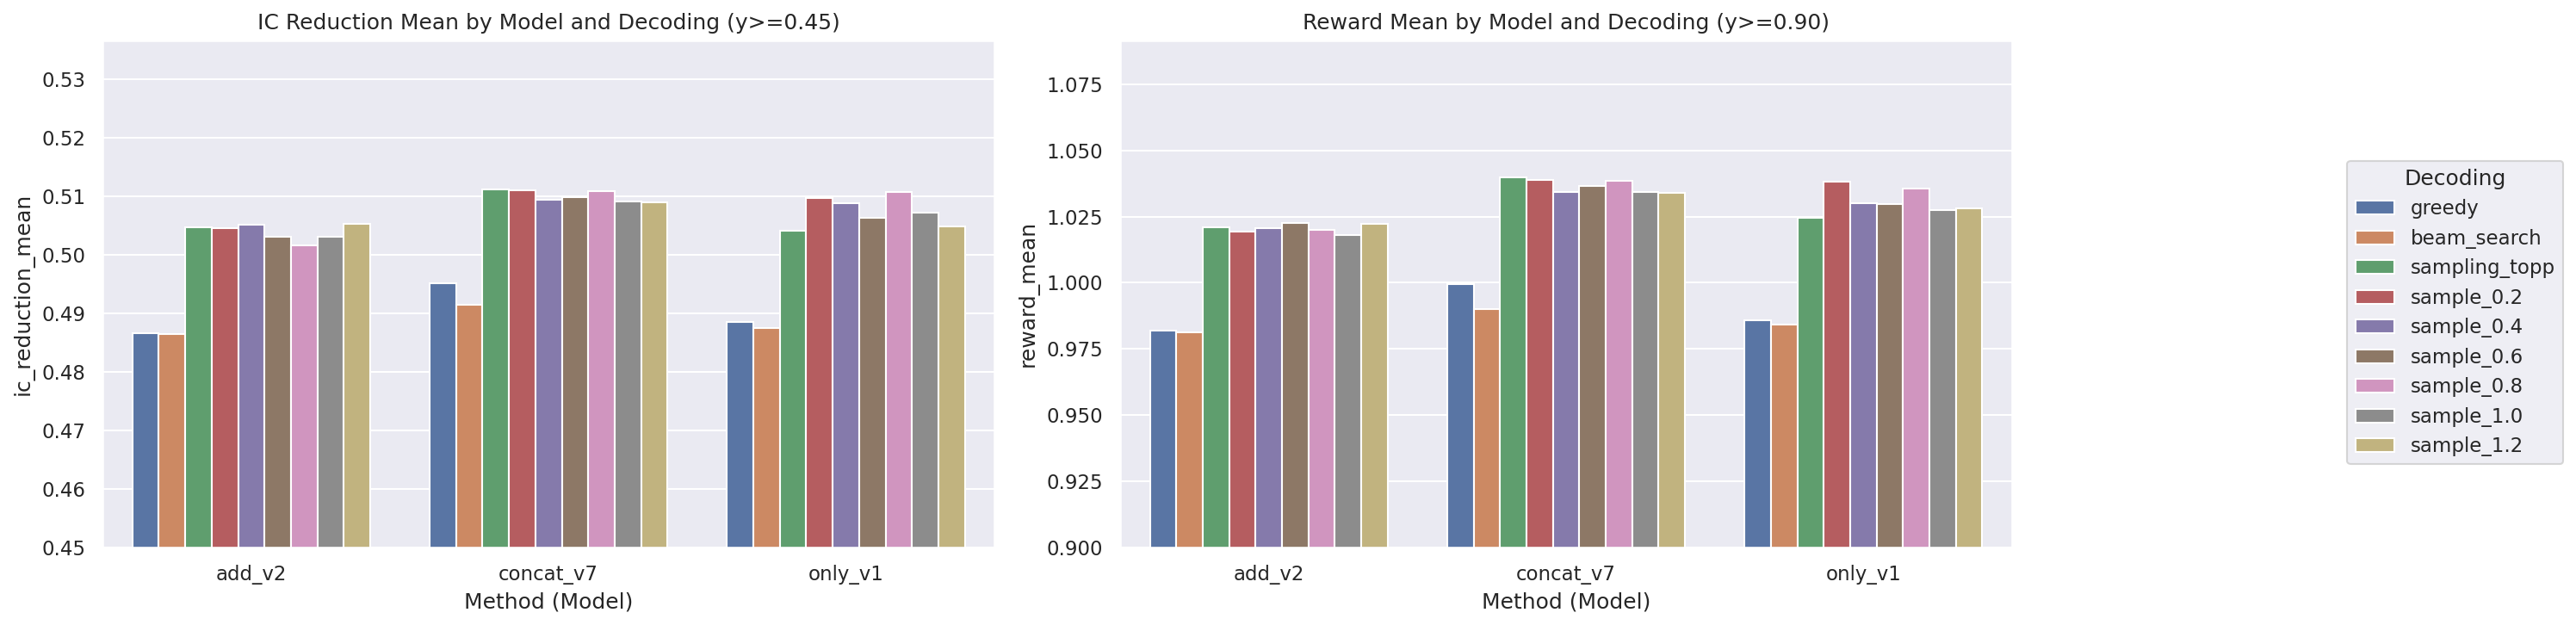

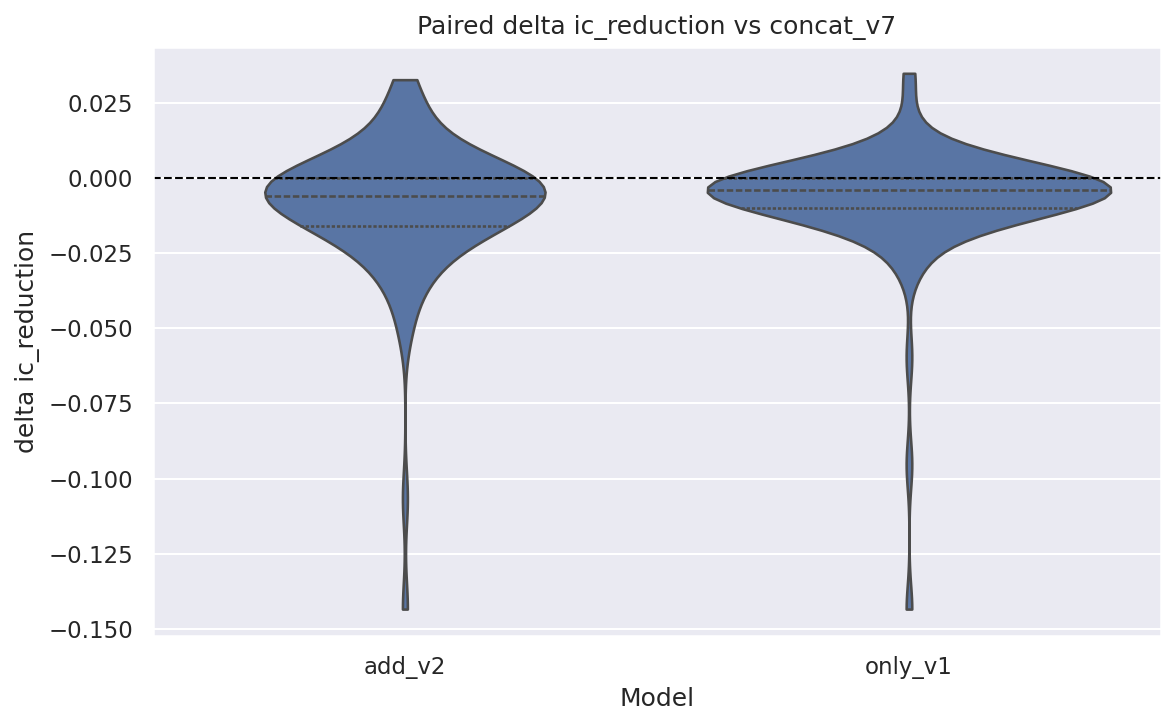

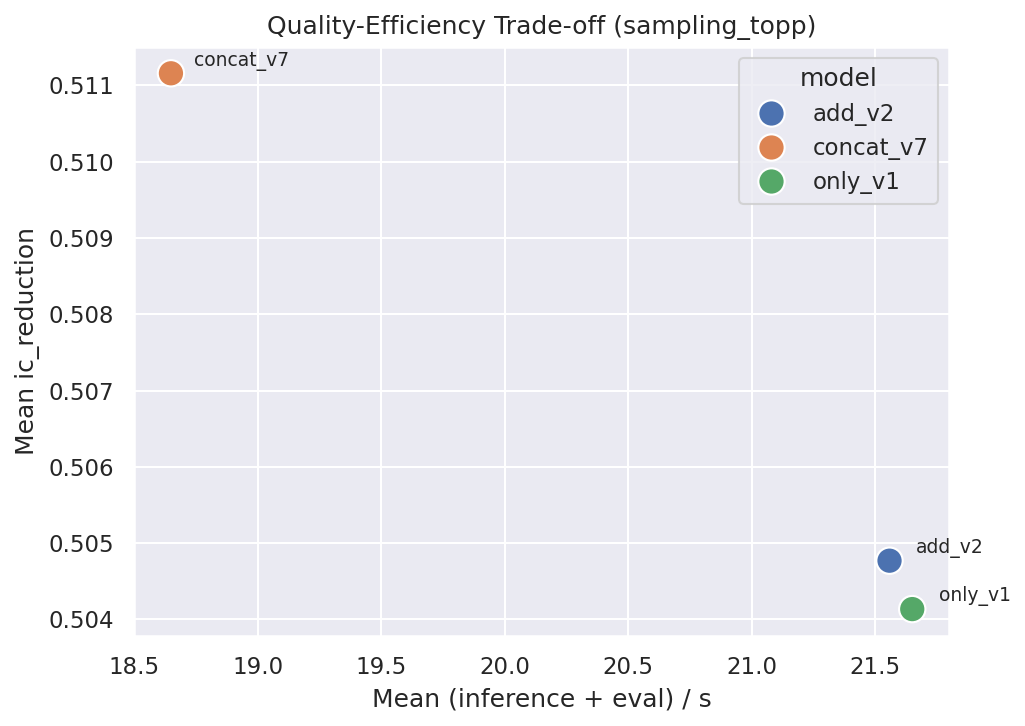


=== Draft result summary (sampling_topp-controlled) ===
Best model on ic_reduction_mean: concat_v7 (ic_reduction_mean=0.511158, reward_mean=1.039723).
Most efficient model (inference+eval): concat_v7 (time_main=18.648s).
See pair_report for paired deltas/CI/win-rate vs concat_v7.


In [12]:
# 以 concat_v7 为基线，做配对 benchmark 差值统计
BASE_MODEL = "concat_v7"

base_df = sampling_topp_df[sampling_topp_df["model"] == BASE_MODEL][["benchmark", "reward_max", "ic_reduction"]].copy()
base_df = base_df.rename(columns={"reward_max": "base_reward", "ic_reduction": "base_ic"})

pair_rows = []
delta_records = []
rng = np.random.default_rng(42)

for model in sorted(sampling_topp_df["model"].unique()):
    if model == BASE_MODEL:
        continue
    cur = sampling_topp_df[sampling_topp_df["model"] == model][["benchmark", "reward_max", "ic_reduction"]].copy()
    merged = cur.merge(base_df, on="benchmark", how="inner")

    d_ic = (merged["ic_reduction"] - merged["base_ic"]).to_numpy(float)
    d_rw = (merged["reward_max"] - merged["base_reward"]).to_numpy(float)

    def _boot_ci(x, n_boot=3000, alpha=0.05):
        x = x[np.isfinite(x)]
        if len(x) == 0:
            return np.nan, np.nan, np.nan
        boots = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(n_boot)]
        return float(x.mean()), float(np.quantile(boots, alpha/2)), float(np.quantile(boots, 1-alpha/2))

    ic_mean, ic_l, ic_u = _boot_ci(d_ic)
    rw_mean, rw_l, rw_u = _boot_ci(d_rw)

    pair_rows.append({
        "compare_to": BASE_MODEL,
        "model": model,
        "n_common_benchmarks": int(len(merged)),
        "delta_ic_mean": ic_mean,
        "delta_ic_ci_low": ic_l,
        "delta_ic_ci_high": ic_u,
        "ic_win_rate": float((d_ic > 0).mean()) if len(d_ic) else np.nan,
        "delta_reward_mean": rw_mean,
        "delta_reward_ci_low": rw_l,
        "delta_reward_ci_high": rw_u,
        "reward_win_rate": float((d_rw > 0).mean()) if len(d_rw) else np.nan,
    })

    delta_records.append(pd.DataFrame({
        "model": model,
        "delta_ic": d_ic,
        "delta_reward": d_rw,
    }))

pair_report = pd.DataFrame(pair_rows).sort_values("delta_ic_mean", ascending=False)
print("=== Paired comparison vs concat_v7 (sampling_topp only) ===")
display(pair_report)

delta_df = pd.concat(delta_records, ignore_index=True) if delta_records else pd.DataFrame()

# 图1：丰富方法集对比（greedy / beam_search / sampling_topp / 各温度sample）
rich_df = main_table_all.copy()

# 构造方法显示名
rich_df["method_show"] = rich_df.apply(
    lambda r: (
        "greedy" if r["mode"] == "greedy" else
        "beam_search" if r["mode"] == "beam" else
        "sampling_topp" if r["mode"] == "sampling_topp" else
        str(r["sampling_key"]) if r["mode"] == "sampling" else
        None
    ),
    axis=1,
)

rich_df = rich_df[rich_df["method_show"].notna()].copy()

temp_methods = sorted(
    [m for m in rich_df["method_show"].unique().tolist() if str(m).startswith("sample_")],
    key=lambda s: float(str(s).split("sample_", 1)[1]),
)
method_order = ["greedy", "beam_search", "sampling_topp"] + temp_methods

model_order = sorted(rich_df["model"].unique().tolist())

# 图1+图2：IC reduction 与 Reward 并排展示（左右排布）
fig, (ax_ic, ax_rw) = plt.subplots(1, 2, figsize=(18, 5), dpi=150)

sns.barplot(
    data=rich_df,
    x="model",
    y="ic_reduction_mean",
    hue="method_show",
    hue_order=method_order,
    order=model_order,
    ax=ax_ic,
)
ax_ic.set_title("IC Reduction Mean by Model and Decoding (y>=0.45)")
ax_ic.set_xlabel("Method (Model)")
ax_ic.set_ylabel("ic_reduction_mean")
ax_ic.set_ylim(0.45, None)
ax_ic.tick_params(axis="x", rotation=0)

sns.barplot(
    data=rich_df,
    x="model",
    y="reward_mean",
    hue="method_show",
    hue_order=method_order,
    order=model_order,
    ax=ax_rw,
)
ax_rw.set_title("Reward Mean by Model and Decoding (y>=0.90)")
ax_rw.set_xlabel("Method (Model)")
ax_rw.set_ylabel("reward_mean")
ax_rw.set_ylim(0.90, None)
ax_rw.tick_params(axis="x", rotation=0)

# 合并为一个全局图例，避免左右子图重复图例
handles, labels = ax_ic.get_legend_handles_labels()
if ax_ic.legend_ is not None:
    ax_ic.legend_.remove()
if ax_rw.legend_ is not None:
    ax_rw.legend_.remove()
fig.legend(handles, labels, title="Decoding", bbox_to_anchor=(0.93, 0.5), loc="center left")

plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

# 图2：相对 concat_v7 的配对 delta_ic 分布
if not delta_df.empty:
    plt.figure(figsize=(8, 5), dpi=150)
    sns.violinplot(data=delta_df, x="model", y="delta_ic", inner="quart", cut=0)
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.title("Paired delta ic_reduction vs concat_v7")
    plt.xlabel("Model")
    plt.ylabel("delta ic_reduction")
    plt.tight_layout()
    plt.show()

# 图3：效率-效果散点图（sampling_topp）
se = sampling_topp_summary.copy()
se["time_main"] = se["inference_time_mean"] + se["eval_time_mean"]

plt.figure(figsize=(7, 5), dpi=150)
sns.scatterplot(data=se, x="time_main", y="ic_reduction_mean", hue="model", s=160)
for _, r in se.iterrows():
    plt.text(r["time_main"]*1.005, r["ic_reduction_mean"]+0.0001, r["model"], fontsize=9)
plt.title("Quality-Efficiency Trade-off (sampling_topp)")
plt.xlabel("Mean (inference + eval) / s")
plt.ylabel("Mean ic_reduction")
plt.tight_layout()
plt.show()

# 自动摘要（论文可改写）
best = sampling_topp_summary.sort_values("ic_reduction_mean", ascending=False).iloc[0]
fast = se.sort_values("time_main", ascending=True).iloc[0]
print("\n=== Draft result summary (sampling_topp-controlled) ===")
print(
    f"Best model on ic_reduction_mean: {best['model']} "
    f"(ic_reduction_mean={best['ic_reduction_mean']:.6f}, reward_mean={best['reward_mean']:.6f})."
)
print(
    f"Most efficient model (inference+eval): {fast['model']} "
    f"(time_main={fast['time_main']:.3f}s)."
)
print("See pair_report for paired deltas/CI/win-rate vs concat_v7.")